In [1]:
import torch
import torch.nn 

from torch.func import (vmap, jacrev)

import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append('.')
sys.path.append('..')
sys.path.append('neural_model_identification')

from neural_model_identification.physics_models.unicycle_kin import Unicycle
from neural_model_identification.parameters.train_params_pinn import TrainParamsPinn
from neural_model_identification.data_generation.preprocess_pinn import DataPreProcess


In [2]:
preProcess = DataPreProcess()
dataset, extra_features = preProcess.run()

In [47]:



class MLP(torch.nn.Module):

    def __init__(
        self,
        state_dim,
        input_dim,
        latent_dim,
        n_hidden_layer=2,
        time=False
    ):
        super(MLP, self).__init__()

        self.input_shape = state_dim + input_dim
        if time:
            self.input_shape += 1
        self.state_dim = state_dim

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(self.input_shape, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, state_dim),
        )

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x has dimension [batch_size, state_dim + action_dim + state_dim]
        """
        return self.fc(x)



class MLP_double_branch(torch.nn.Module):
    
    def __init__(self,
        state_dim,
        input_dim,
        latent_dim,
        n_hidden_layer=2,
        time=False
    ):
        super(MLP_double_branch, self).__init__()

        self.input_shape = state_dim + input_dim
        if time:
            self.input_shape += 1
        self.state_dim = state_dim

        self.fc_input_action = torch.nn.Linear(input_dim, 10)
        self.fc_latent_action = torch.nn.Linear(10, input_dim)

        self.fc_input_state = torch.nn.Linear(state_dim, 10)
        self.fc_latent_state = torch.nn.Linear(10, state_dim)

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(self.input_shape, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, latent_dim),
            torch.nn.Tanh(),
            torch.nn.Linear(latent_dim, state_dim),
        )

    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x has dimension [batch_size, state_dim + action_dim + state_dim]
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)

        x_state = x[:, :self.state_dim]
        x_action = x[:, self.state_dim:-1]
        x_time = x[:, -1]

        x_latent_state = self.fc_latent_state(
            torch.tanh(self.fc_input_state(x_state))
        )

        x_latent_action = self.fc_latent_action(
            torch.tanh(self.fc_input_action(x_action))
        )


        print(
            x_latent_action.shape, x_latent_state.shape, x_time.shape
        )
        x = torch.vstack([x_latent_state, x_latent_action, x_time])

        return self.fc(x)


In [41]:

class Pinn_learner:


    def __init__(
        self,
        ode_fn,
        params,
        dataset,
        input_range,
        use_pretrain=False, 
        device="cuda"):
        
        
        # robot model, dynamics
        self.state_dim = params.state_dim
        self.input_dim = params.input_dim
        self.ode_fn = ode_fn


        self.model_path = params.model_path
        self.device = device
        self.model = MLP_double_branch(
            state_dim=params.state_dim,
            input_dim=params.input_dim,
            n_hidden_layer=params.n_hidden_layer,
            latent_dim=params.latent_dim,
            time=True
        ).to(self.device)

        if params.use_pretrain:
            print("loading pretrain model")
            self.model.load_state_dict(torch.load(self.model_path, weights_only=True))
        
        # dataset 
        self.dataset = dataset.to(self.device)
        self.dataloader = torch.utils.data.DataLoader(
            self.dataset, 
            batch_size=params.batch_size, 
            shuffle=True
        )

        self.particle_batch_size_boundary = params.particle_batch_size_boundary
        self.particle_batch_size_gradient = params.particle_batch_size_gradient

        self.max_range = input_range[0].to(self.device)
        self.min_range = input_range[1].to(self.device) 
        #self.batch_size = None
        #self.particle_batch_size_boundary = None
        #self.particle_batch_size_gradient = None

        #self.config_batch_size(
        #    params.batch_size, 
        #    params.particle_batch_size_boundary,
        #    params.particle_batch_size_gradient
        #)

        # training component 
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=params.lr,
            weight_decay=params.weight_decay
        )

        self.imit_loss_weight = params.imit_loss_weight
        self.boundary_loss_weight = params.boundary_loss_weight
        self.physic_loss_weight = params.physic_loss_weight

        self.mse = torch.nn.MSELoss()


    # training functions
    # -------------------
    def calc_loss(self, batch):
        
        statistics = {}
        if self.imit_loss_weight > 0:
            imit_loss = self.calc_mse_loss(batch)
            statistics['imit_loss'] = imit_loss.item()
        
        if self.boundary_loss_weight > 0:
            boundary_loss = self.calc_boundary_loss()
            statistics['boundary_loss'] = boundary_loss.item()

        if self.physic_loss_weight > 0:
            physic_loss = self.calc_physic_loss()
            statistics['physic_loss'] = physic_loss.item()

        loss = imit_loss + boundary_loss + physic_loss
        statistics['total_loss'] = loss.item()

        return loss, statistics

    def train_step(self):
        for i, batch in enumerate(self.dataloader):
            self.optimizer.zero_grad()
            loss, stat = self.calc_loss(batch)
            loss.backward()
            self.optimizer.step()
        return stat


    # loss definition
    # -------------------
    def calc_physic_loss(self):

        N_particle = self.particle_batch_size_gradient

        # sample the particle        
        sampled_input = torch.rand(N_particle, self.state_dim + self.input_dim + 1).to(self.device)
        # normalize the particle in the respective range
        sampled_input = sampled_input * (self.max_range - self.min_range) + self.min_range
        sampled_input.requires_grad = True

        # pinn prediction
        pred_output = self.model(sampled_input)

        # jacobian --> [batch, state_dim, (state_dim + input_dim + 1(time))]
        jac = vmap(jacrev(self.model))(sampled_input).squeeze()
        state_derivative_numeric = jac[:, :, -1]        

        # ode prediction
        state_derivative_analytic = self.ode_fn(
            sampled_input[:, :self.state_dim],
            sampled_input[:, self.state_dim:-1]
        )

        # error:  
        error = state_derivative_numeric - state_derivative_analytic

        # scale up the error over the orientation:
        error[:, 2] = error[:, 2] * 1.8

        # physics cost:
        physic_loss = torch.mean(error**2)
                        #torch.mean(
            #    torch.square(state_derivative_numeric - state_derivative_analytic),
            #    dim=1
        

        return self.physic_loss_weight * physic_loss

    def calc_mse_loss(self, batch):
        X, Y = batch[:, :-self.state_dim], batch[:, -self.state_dim:]
        pred_y = self.model(X)
        return self.imit_loss_weight * self.mse(pred_y, Y)

    def calc_boundary_loss(self):
        N_particle = self.particle_batch_size_boundary

        # sample the particle
        sampled_input = torch.rand(N_particle, self.state_dim + self.input_dim + 1).to(self.device)
        
        # normalize in the respective range 
        sampled_input = sampled_input * (self.max_range - self.min_range) + self.min_range
        
        # zeros the velocity
        sampled_input[:, self.state_dim:self.state_dim+self.input_dim] = 0.0
        

        # 0 velocity means that we want to predict the initial state 
        # the models must be a kind of identity function 
        target_prediction = sampled_input[:, :self.state_dim].clone()

        sampled_input.requires_grad = True
        pred_output = self.model(sampled_input)
        boundary_loss = self.mse(pred_output, target_prediction)

        return self.boundary_loss_weight * boundary_loss










In [26]:
min_range, max_range = dataset.min(0)[0][:-3], dataset.max(0)[0][:-3]

In [1]:
TrainParamsPinn.state_dim, 
TrainParamsPinn.input_dim,
TrainParamsPinn.latent_dim,
TrainParamsPinn.n_hidden_layer = 4
TrainParamsPinn.batch_size = 1024
TrainParamsPinn.particle_batch_size_boundary = 200
TrainParamsPinn.particle_batch_size_gradient = 200
TrainParamsPinn.use_pretrain = False
TrainParamsPinn.weight_decay = 1e-9
TrainParamsPinn.lr = 1e-6
TrainParamsPinn.imit_loss_weight = 1.0
TrainParamsPinn.boundary_loss_weight = 0.1
TrainParamsPinn.physic_loss_weight = 0.1


NameError: name 'TrainParamsPinn' is not defined

In [27]:
def unikin_ode(state, action):
    x, y, theta = state[:, 0], state[:, 1], state[:, 2]
    v, w = action[:, 0], action[:, 1]

    x_dot = v * torch.cos(theta)
    y_dot = v * torch.sin(theta)
    theta_dot = w

    return torch.stack([x_dot, y_dot, theta_dot], dim=1)

In [49]:
TrainParamsPinn.use_pretrain = False

learner = Pinn_learner(
    ode_fn = unikin_ode, 
    params=TrainParamsPinn,
    dataset=dataset, 
    input_range=(max_range, min_range), 
    device='cuda'
)

epoch_counter = 0

In [38]:
stat_log = {
    'total_loss': [],
    'imit_loss': [],
    'boundary_loss': [],
    'physic_loss': []
}


In [50]:

for epoch in range(10_000):
    epoch_counter += 1
    stat = learner.train_step()

    stat_log['total_loss'].append(stat['total_loss'])
    stat_log['imit_loss'].append(stat['imit_loss'])
    stat_log['boundary_loss'].append(stat['boundary_loss'])
    stat_log['physic_loss'].append(stat['physic_loss'])

    if epoch % 10 == 0:
        print(f"stat {epoch_counter}: tot: {stat['total_loss']}, imit: {stat['imit_loss']}, boundary: {stat['boundary_loss']}, physic: {stat['physic_loss']}")

    if epoch % 100 == 0:
        torch.save(learner.model, f'models_logs/pinn_uniKin_epochs_{epoch_counter}.pth')


RuntimeError: Sizes of tensors must match except in dimension 0. Expected size 3 but got size 2 for tensor number 1 in the list.

1063

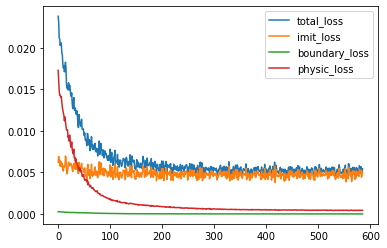

In [17]:
skip_first = 800

plt.plot(stat_log['total_loss'][skip_first::5], label='total_loss')
plt.plot(stat_log['imit_loss'][skip_first::5], label='imit_loss')
plt.plot(stat_log['boundary_loss'][skip_first::5], label='boundary_loss')
plt.plot(stat_log['physic_loss'][skip_first::5], label='physic_loss')
plt.legend()

In [18]:
x0 = torch.Tensor([0.0, 0.0, 0.0]).unsqueeze(0)
action = torch.rand(50, 2) 
action[:, 0] += torch.randn(50) * 0.1
action[:, 1] += torch.randn(50) * 0.1
t = torch.Tensor([TrainParamsPinn.dt]).unsqueeze(0)    

In [19]:
traj = []
x = x0
for id_action in range(len(action)):
    with torch.no_grad():
        input_pair = torch.cat([x0, action[id_action].unsqueeze(0), t], dim=1)
        input_pair = input_pair.to('cuda')

        x = learner.model(input_pair)
    traj.append(x)



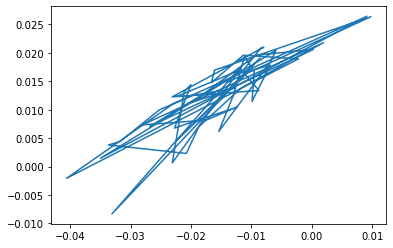

In [20]:
traj_net = torch.stack(traj).squeeze().cpu().numpy()
plt.plot(traj_net[:, 0], traj_net[:, 1], label='net')

In [21]:
traj = [x0]
state = x0
for id in range(len(action)):
    
    dx = unikin_ode(state, action[id].unsqueeze(0))

    state = state + dx * t
    traj.append(state)

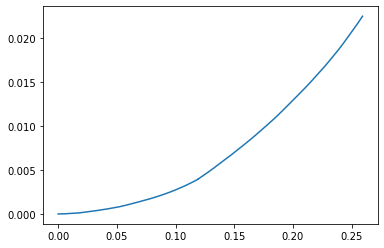

In [22]:
traj_analytic = torch.stack(traj).squeeze().cpu().numpy()
plt.plot(traj_analytic[:, 0], traj_analytic[:, 1], label='analytic')